# Aula 02 - Análise Morfológica e Sintática

**Curso:** Processamento de Linguagem Natural  
**Aluno:** [Seu Nome Aqui]  
**Data:** [Data Atual]

## Instruções
1. Complete todos os exercícios marcados com `# === SEU CÓDIGO AQUI ===`
2. Execute as células de teste para verificar suas respostas
3. **Não modifique as células de teste**
4.  Execute todas as células em ordem
5.  Respostas devem ser armazenadas nas variáveis indicadas

## Critérios de Avaliação
- **Conteúdo (100%):** Testes automáticos

---

## Dataset

Utilizaremos o dataset **B2W-Reviews01** com reviews de e-commerce brasileiro.


## Setup

In [1]:
# === CONFIGURAÇÃO INICIAL ===

!pip install --upgrade pip --quiet
!pip cache purge
!pip install otter-grader --no-cache-dir -q
!pip install spacy --quiet
!python -m spacy download pt_core_news_sm --quiet
!mkdir -p tests

print("Ambiente configurado!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.9 MB/s eta 0:00:00
Files removed: 6 (1.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Ambiente configurado!


In [2]:
%%writefile tests/q1.py
OK_FORMAT = True

test = {
    "name": "q1",
    "points": 10,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se variáveis existem
                    >>> assert 'doc_processado' in dir(), "Variável doc_processado não foi criada"
                    >>> assert 'lista_tokens' in dir(), "Variável lista_tokens não foi criada"
                    >>> assert 'lista_lemas' in dir(), "Variável lista_lemas não foi criada"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> import spacy
                    >>> # Verificar tipo do doc
                    >>> assert isinstance(doc_processado, spacy.tokens.Doc), "doc_processado deve ser um objeto Doc do spaCy"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar listas
                    >>> assert isinstance(lista_tokens, list), "lista_tokens deve ser uma lista"
                    >>> assert isinstance(lista_lemas, list), "lista_lemas deve ser uma lista"
                    >>> assert len(lista_tokens) > 0, "lista_tokens não deve estar vazia"
                    >>> assert len(lista_lemas) == len(lista_tokens), "lista_lemas deve ter mesmo tamanho que lista_tokens"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q1.py


In [3]:
%%writefile tests/q2.py
OK_FORMAT = True

test = {
    "name": "q2",
    "points": 10,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(extrair_por_pos), "Função extrair_por_pos não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar extração de substantivos
                    >>> teste_doc = nlp("O cliente comprou o produto")
                    >>> nouns = extrair_por_pos(teste_doc, 'NOUN')
                    >>> assert isinstance(nouns, list), "Deve retornar uma lista"
                    >>> assert 'cliente' in nouns or 'produto' in nouns, "Deve extrair substantivos corretamente"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar extração de adjetivos
                    >>> teste_doc = nlp("Produto excelente e entrega rápida")
                    >>> adjs = extrair_por_pos(teste_doc, 'ADJ')
                    >>> assert len(adjs) >= 1, "Deve extrair pelo menos 1 adjetivo"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q2.py


In [4]:
%%writefile tests/q3.py
OK_FORMAT = True

test = {
    "name": "q3",
    "points": 10,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar variáveis
                    >>> assert 'contagem_pos' in dir(), "Variável contagem_pos não foi criada"
                    >>> assert 'pos_mais_frequente' in dir(), "Variável pos_mais_frequente não foi criada"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> from collections import Counter
                    >>> # Verificar tipo
                    >>> assert isinstance(contagem_pos, Counter), "contagem_pos deve ser um Counter"
                    >>> assert isinstance(pos_mais_frequente, str), "pos_mais_frequente deve ser uma string"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar conteúdo
                    >>> assert len(contagem_pos) > 0, "contagem_pos não deve estar vazio"
                    >>> assert pos_mais_frequente in ['NOUN', 'VERB', 'ADJ', 'ADV', 'ADP', 'DET', 'PRON', 'PUNCT', 'PROPN'], "pos_mais_frequente deve ser uma POS tag válida"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q3.py


In [5]:
%%writefile tests/q4.py
OK_FORMAT = True

test = {
    "name": "q4",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(extrair_relacoes_dependencia), "Função extrair_relacoes_dependencia não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> teste_doc = nlp("O cliente comprou o produto")
                    >>> resultado = extrair_relacoes_dependencia(teste_doc)
                    >>> assert isinstance(resultado, list), "Deve retornar uma lista"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar formato das tuplas
                    >>> teste_doc = nlp("O gato dormiu")
                    >>> resultado = extrair_relacoes_dependencia(teste_doc)
                    >>> assert all(isinstance(item, tuple) for item in resultado), "Cada elemento deve ser uma tupla"
                    >>> assert all(len(item) == 3 for item in resultado), "Cada tupla deve ter 3 elementos (token, dep, head)"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q4.py


In [6]:
%%writefile tests/q5.py
OK_FORMAT = True

test = {
    "name": "q5",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar variáveis
                    >>> assert 'noun_chunks_lista' in dir(), "Variável noun_chunks_lista não foi criada"
                    >>> assert 'sujeitos_encontrados' in dir(), "Variável sujeitos_encontrados não foi criada"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar tipos
                    >>> assert isinstance(noun_chunks_lista, list), "noun_chunks_lista deve ser uma lista"
                    >>> assert isinstance(sujeitos_encontrados, list), "sujeitos_encontrados deve ser uma lista"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar conteúdo
                    >>> assert len(noun_chunks_lista) > 0, "noun_chunks_lista não deve estar vazia"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q5.py


In [7]:
%%writefile tests/q6.py
OK_FORMAT = True

test = {
    "name": "q6",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(extrair_entidades), "Função extrair_entidades não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> teste_doc = nlp("A Microsoft abriu escritório em São Paulo")
                    >>> resultado = extrair_entidades(teste_doc)
                    >>> assert isinstance(resultado, dict), "Deve retornar um dicionário"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar estrutura
                    >>> teste_doc = nlp("João trabalha na Petrobras")
                    >>> resultado = extrair_entidades(teste_doc)
                    >>> assert all(isinstance(v, list) for v in resultado.values()), "Valores do dicionário devem ser listas"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q6.py


In [8]:
%%writefile tests/q7.py
OK_FORMAT = True

test = {
    "name": "q7",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(extrair_aspecto_opiniao), "Função extrair_aspecto_opiniao não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar com review simples
                    >>> teste_doc = nlp("Produto excelente")
                    >>> resultado = extrair_aspecto_opiniao(teste_doc)
                    >>> assert isinstance(resultado, list), "Deve retornar uma lista"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar formato
                    >>> teste_doc = nlp("Qualidade ótima e preço justo")
                    >>> resultado = extrair_aspecto_opiniao(teste_doc)
                    >>> if len(resultado) > 0:
                    ...     assert all(isinstance(item, tuple) and len(item) == 2 for item in resultado), "Cada item deve ser tupla (aspecto, adjetivos)"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q7.py


In [9]:
%%writefile tests/q8.py
OK_FORMAT = True

test = {
    "name": "q8",
    "points": 12,
    "suites": [
        {
            "cases": [
                {
                    "code": r"""
                    >>> # Verificar se função existe
                    >>> assert callable(analisar_review_completo), "Função analisar_review_completo não foi definida"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Testar retorno
                    >>> resultado = analisar_review_completo("Produto excelente, entrega rápida!")
                    >>> assert isinstance(resultado, dict), "Deve retornar um dicionário"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar chaves obrigatórias
                    >>> resultado = analisar_review_completo("Teste de review")
                    >>> chaves_obrigatorias = ['num_tokens', 'substantivos', 'adjetivos', 'verbos', 'entidades']
                    >>> assert all(chave in resultado for chave in chaves_obrigatorias), "Dicionário deve conter todas as chaves obrigatórias"
                    """,
                    "hidden": False,
                    "locked": False
                },
                {
                    "code": r"""
                    >>> # Verificar tipos dos valores
                    >>> resultado = analisar_review_completo("O produto chegou bem")
                    >>> assert isinstance(resultado['num_tokens'], int), "num_tokens deve ser inteiro"
                    >>> assert isinstance(resultado['substantivos'], list), "substantivos deve ser lista"
                    >>> assert isinstance(resultado['adjetivos'], list), "adjetivos deve ser lista"
                    """,
                    "hidden": False,
                    "locked": False
                }
            ],
            "scored": True,
            "setup": "",
            "teardown": "",
            "type": "doctest"
        }
    ]
}

Writing tests/q8.py


In [10]:
# Imports e configurações
import otter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# spaCy
import spacy
from spacy import displacy

# Carregar modelo português
nlp = spacy.load('pt_core_news_sm')

# Configurações
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Inicializar grader
grader = otter.Notebook()

print("✓ Setup completo!")
print(f"✓ spaCy versão: {spacy.__version__}")

✓ Setup completo!
✓ spaCy versão: 3.8.11


## Carregar Dados

In [11]:
# Carregar dataset
url_dataset = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"
df_reviews = pd.read_csv(url_dataset, nrows=500)
df_reviews = df_reviews.dropna(subset=['review_text'])

print(f"Dataset carregado: {len(df_reviews)} reviews")
df_reviews[['review_text', 'overall_rating']].head()

Dataset carregado: 493 reviews


,review_text,overall_rating
0,Estou contente com a compra entrega rápida o ú...,4
1,"Por apenas R$1994.20,eu consegui comprar esse ...",4
2,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,4
3,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,4
4,"A entrega foi no prazo, as americanas estão de...",5


---

## Exercício 1: Processamento Básico com spaCy

Usando a primeira review do dataset (`df_reviews['review_text'].iloc[0]`):

1. Processe o texto com `nlp()` e armazene em `doc_processado`
2. Crie `lista_tokens`: lista com o texto de cada token (apenas alfabéticos, use `token.is_alpha`)
3. Crie `lista_lemas`: lista com o lema de cada token (apenas alfabéticos)

In [12]:
# === SEU CÓDIGO AQUI ===

texto = df_reviews['review_text'].iloc[0]
doc_processado = nlp(texto)

lista_tokens = [token.text for token in doc_processado if token.is_alpha]
lista_lemas = [token.lemma_ for token in doc_processado if token.is_alpha]

In [13]:
grader.check("q1")

q1 results: All test cases passed!

---

## Exercício 2: Extração por Classe Gramatical

Crie uma função `extrair_por_pos` que:

1. Recebe um objeto `doc` do spaCy e uma `pos_tag` (string)
2. Retorna uma lista com o texto dos tokens que possuem a POS tag especificada
3. Deve retornar apenas tokens alfabéticos (use `token.is_alpha`)

**Dica:** Use `token.pos_` para verificar a POS tag.

In [14]:
# === SEU CÓDIGO AQUI ===

def extrair_por_pos(doc, pos_tag):
    return [token.text for token in doc if token.pos_ == pos_tag and token.is_alpha]

In [15]:
grader.check("q2")

q2 results: All test cases passed!

---

## Exercício 3: Estatísticas de POS Tags

Analise a distribuição de POS tags nas primeiras 100 reviews:

1. Processe as primeiras 100 reviews com `nlp.pipe()`
2. Conte a frequência de cada POS tag (apenas tokens alfabéticos)
3. Armazene o resultado em `contagem_pos` (use `Counter`)
4. Armazene a POS tag mais frequente em `pos_mais_frequente`

In [16]:
# === SEU CÓDIGO AQUI ===

docs = list(nlp.pipe(df_reviews['review_text'].iloc[:100]))

contagem_pos = Counter()
for doc in docs:
    for token in doc:
        if token.is_alpha:
            contagem_pos[token.pos_] += 1

pos_mais_frequente = contagem_pos.most_common(1)[0][0]

In [17]:
grader.check("q3")

q3 results: All test cases passed!

---

## Exercício 4: Análise de Dependências

Crie uma função `extrair_relacoes_dependencia` que:

1. Recebe um objeto `doc` do spaCy
2. Retorna uma lista de tuplas `(token, dep, head)` onde:
   - `token`: texto do token
   - `dep`: relação de dependência (`token.dep_`)
   - `head`: texto do token pai (`token.head.text`)
3. Inclua apenas tokens alfabéticos

In [18]:
# === SEU CÓDIGO AQUI ===

def extrair_relacoes_dependencia(doc):
    relacoes = []
    for token in doc:
        if token.is_alpha:
            relacoes.append((token.text, token.dep_, token.head.text))
    return relacoes

In [19]:
grader.check("q4")

q4 results: All test cases passed!

---

## Exercício 5: Noun Chunks e Sujeitos

Usando a terceira review do dataset (`df_reviews['review_text'].iloc[2]`):

1. Processe a review com `nlp()`
2. Extraia todos os noun chunks e armazene seus textos em `noun_chunks_lista`
3. Extraia os sujeitos nominais (tokens com `dep_` igual a `'nsubj'`) e armazene em `sujeitos_encontrados`

In [20]:
# === SEU CÓDIGO AQUI ===

doc = nlp(df_reviews['review_text'].iloc[2])

noun_chunks_lista = [chunk.text for chunk in doc.noun_chunks]
sujeitos_encontrados = [token.text for token in doc if token.dep_ == 'nsubj']

In [21]:
grader.check("q5")

q5 results: All test cases passed!

---

## Exercício 6: Named Entity Recognition

Crie uma função `extrair_entidades` que:

1. Recebe um objeto `doc` do spaCy
2. Retorna um dicionário onde:
   - Chaves: tipos de entidade (ex: 'PER', 'ORG', 'LOC')
   - Valores: listas com os textos das entidades daquele tipo
3. Se não houver entidades de um tipo, não inclua a chave

In [22]:
# === SEU CÓDIGO AQUI ===

def extrair_entidades(doc):
    entidades = {}
    for ent in doc.ents:
        if ent.label_ not in entidades:
            entidades[ent.label_] = []
        entidades[ent.label_].append(ent.text)
    return entidades

In [23]:
grader.check("q6")

q6 results: All test cases passed!

---

## Exercício 7: Análise de Aspecto-Opinião

Crie uma função `extrair_aspecto_opiniao` que:

1. Recebe um objeto `doc` do spaCy
2. Para cada substantivo (NOUN), encontra os adjetivos (ADJ) que o modificam
   - Um adjetivo modifica um substantivo se é filho direto dele (`token.children`)
3. Retorna uma lista de tuplas `(substantivo, lista_adjetivos)`
4. Inclua apenas pares onde há pelo menos um adjetivo

In [24]:
# === SEU CÓDIGO AQUI ===

def extrair_aspecto_opiniao(doc):
    resultado = []
    for token in doc:
        if token.pos_ == 'NOUN':
            adjs = [child.text for child in token.children if child.pos_ == 'ADJ']
            if adjs:
                resultado.append((token.text, adjs))
    return resultado

In [25]:
grader.check("q7")

q7 results: All test cases passed!

---

## Exercício 8: Pipeline de Análise Completa

Crie uma função `analisar_review_completo` que:

1. Recebe um texto (string)
2. Processa com spaCy
3. Retorna um dicionário contendo:
   - `num_tokens`: número total de tokens
   - `substantivos`: lista de substantivos (NOUN)
   - `adjetivos`: lista de adjetivos (ADJ)
   - `verbos`: lista de lemas dos verbos (VERB)
   - `entidades`: dicionário de entidades (use a função `extrair_entidades`)

In [26]:
# === SEU CÓDIGO AQUI ===

def analisar_review_completo(texto):
    doc = nlp(texto)

    substantivos = [token.text for token in doc if token.pos_ == 'NOUN']
    adjetivos = [token.text for token in doc if token.pos_ == 'ADJ']
    verbos = [token.lemma_ for token in doc if token.pos_ == 'VERB']
    entidades = extrair_entidades(doc)

    return {
        'num_tokens': len(doc),
        'substantivos': substantivos,
        'adjetivos': adjetivos,
        'verbos': verbos,
        'entidades': entidades
    }

In [27]:
grader.check("q8")

q8 results: All test cases passed!

---

## Visualização Extra (Não avaliado)

Execute as células abaixo para visualizar os resultados.

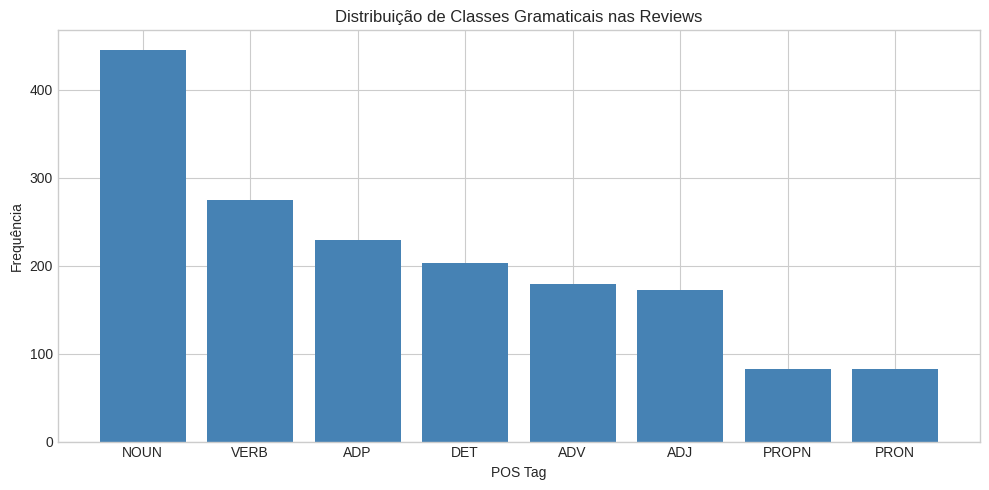

In [28]:
# Visualização da distribuição de POS tags
top_pos = contagem_pos.most_common(8)
labels = [p[0] for p in top_pos]
values = [p[1] for p in top_pos]

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='steelblue')
plt.xlabel('POS Tag')
plt.ylabel('Frequência')
plt.title('Distribuição de Classes Gramaticais nas Reviews')
plt.tight_layout()
plt.show()

In [29]:
# Visualização de dependências
texto_viz = "O cliente satisfeito comprou o produto excelente"
doc_viz = nlp(texto_viz)

print("Árvore de dependências:")
displacy.render(doc_viz, style='dep', jupyter=True, options={'distance': 90})

Árvore de dependências:


---

**Certifique-se de que todos os testes passaram antes de submeter.**